In [44]:
import math
import numpy as np
from tqdm import tqdm
from utils import load_graph
import matplotlib.pyplot as plt
from scipy.stats import truncnorm

## Threshold Distributions

We are working with a truncated normal distribution of thresholds, with abscissae [0,1]. We have the issue of nodes with threshold 0 being spontaneously activated, as an activation occurs when a node has n >= threshold activated neighbors. We therefore bind the lower limit of actual thresholds to 1. 

However, we have the caveat that we are dealing with asymptotically scale-free networks, where a majority of nodes likely have a degree of 1. Therefore, our actual distribution of thresholds likely varies from the ideal truncated normal distribution that we apply.

It is therefore relevant to look at the actual distribution of thresholds.

Question: I can look at three things.
* The fractions returned by the truncated normal function
* The actual thresholds           -> likely to see 1 overrepresented
* Actual threshold / degree       -> likely to see 100% overrepresented

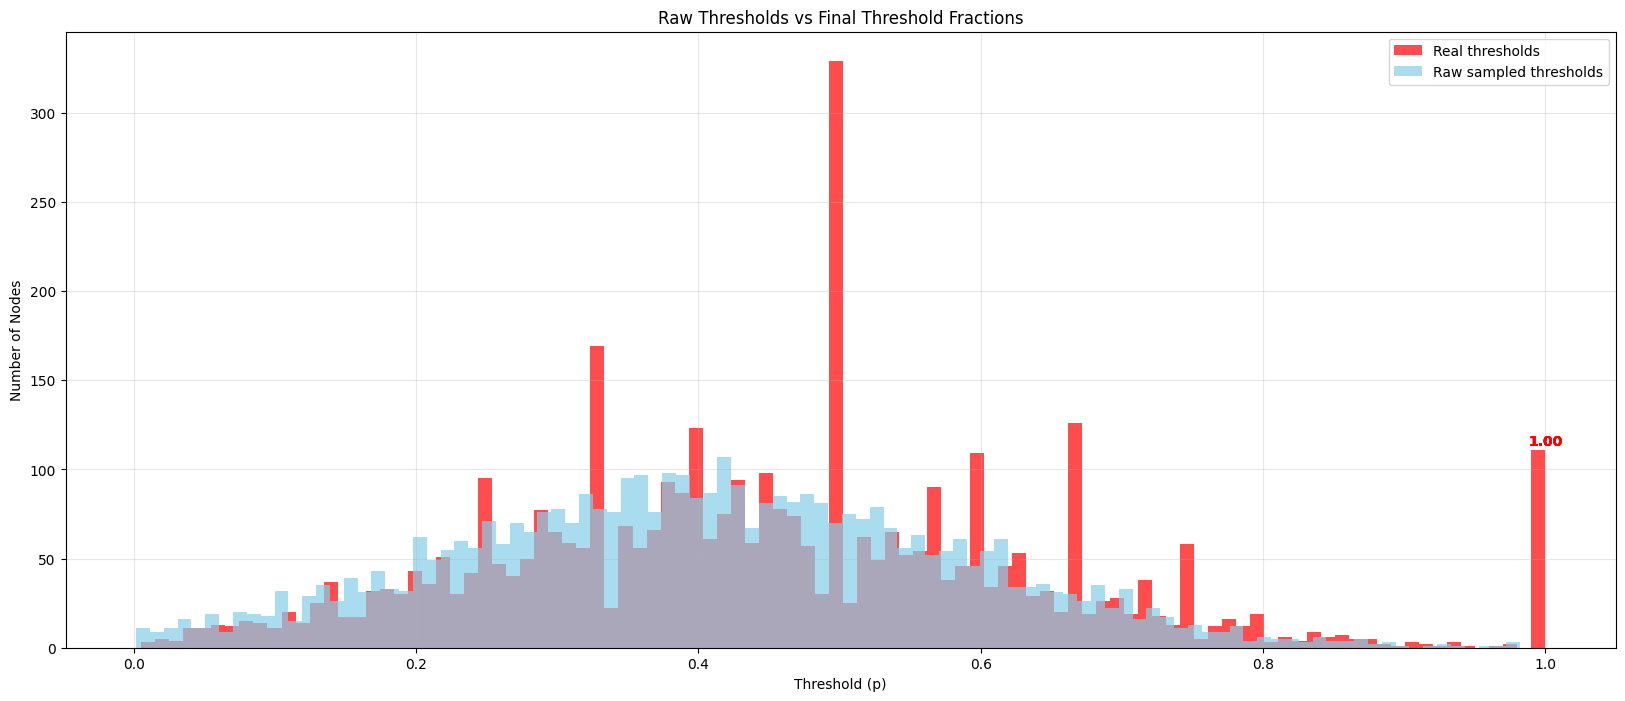

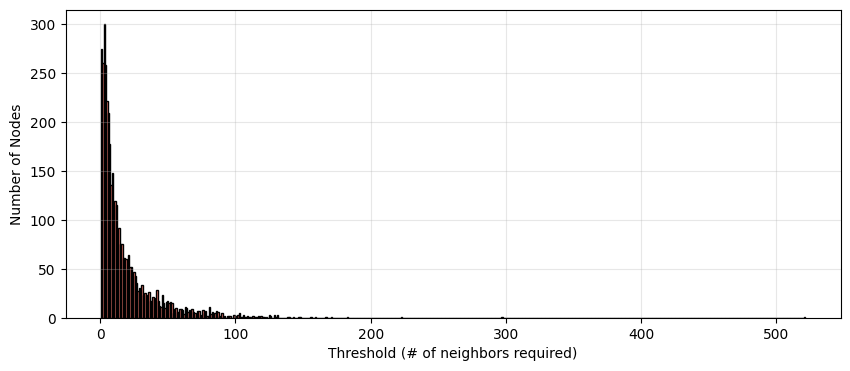

In [47]:
# Data setup
#dataset = "datasets_ignored/wiki.txt"
dataset = "datasets/fb.txt"
G = load_graph(dataset)

# Paramaters
mean = 0.4
std = 0.18

def sample_thresholds(size, mean_threshold, threshold_std):

    lower, upper = 0, 1     # Abscissae of truncated normal distribution

    # Calculate abscissae in standard deviations from mean for truncnorm function
    lower_bound = (lower - mean_threshold) / threshold_std
    upper_bound = (upper - mean_threshold) / threshold_std

    # Sample thresholds
    ps = truncnorm.rvs(lower_bound, upper_bound, loc=mean_threshold, scale=threshold_std, size=size)

    return ps

ps = sample_thresholds(len(G.nodes), mean, std)

thresholds = {}

# Translate thresholds into number of neighbors
for node, avg_p in zip(G.nodes, ps):
    # Randomize threshold to round up so at least 1 neighbor is required
    # for every node to activate (important for low k)
    # Note: in truncnorm, p might be 0
    k = len(list(G.neighbors(node)))
    thresholds[node] = max(1, math.ceil(k * avg_p))    

# Calculate final threshold has fraction of neighbors for comparison with original sampling
threshold_fractions = [threshold / G.degree[node] for node, threshold in thresholds.items()]

plt.figure(figsize=(20, 8))

# Plot the threshold fractions (threshold / node degree)
counts, bins, patches = plt.hist(threshold_fractions, bins=100, color='red', alpha=0.7, histtype="stepfilled", label="Real thresholds")

# Plot the sampled raw thresholds (between 0 and 1)
plt.hist(ps, bins=100, color='skyblue', alpha=0.7, histtype="stepfilled", label="Raw sampled thresholds")

# Highlight the 5 highest thresholds
top5_indices = np.argsort(threshold_fractions)[-5:]  # indices of top 5
top5_values = np.array(threshold_fractions)[top5_indices]

# Add text annotations above the histogram
for val in top5_values:
    # Find the bin index where this value falls
    bin_index = min(np.digitize(val, bins) - 1, len(counts)-1)
    bin_height = counts[bin_index]
    
    plt.text(val, bin_height + 1, f"{val:.2f}", color='red', fontweight='bold',
             ha='center', va='bottom', fontsize=10)

plt.title("Raw Thresholds vs Final Threshold Fractions")
plt.xlabel("Threshold (p)")
plt.ylabel("Number of Nodes")
plt.grid(True, alpha=0.3)

plt.legend()
plt.show()




# Plot the absolute thresholds (number of neighbors required to activate)
plt.figure(figsize=(10, 4))
plt.hist(thresholds.values(), bins=range(1, max(thresholds.values()) + 2), 
         color='salmon', edgecolor='black', align='left')
plt.title("")
plt.xlabel("Threshold (# of neighbors required)")
plt.ylabel("Number of Nodes")
plt.grid(True, alpha=0.3)
plt.show()

    

## Observations

We're actually seeing an overrepresentation of 50% thresholds in the final fractions, but that actually makes sense. Fb is not perfectly scale free and the majority of nodes actually have degree 2. And most of them get threshold = 1.

Interestingly, we're not always seeing the expected spike in the most common actual threshold being 1. 


In the wikipedia set, which is much closer to being scale free and has an extreme majority of nodes with 1 neighbor, we see the expected spike in threshold fraction = 1.